# EDA — MTAT tags, clip graphs, mel
Exploratory look at the preprocessed data used for tasks 1-3.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))
import numpy as np, matplotlib.pyplot as plt
from utils import load_config
cfg = load_config()
proc = Path(cfg['paths']['data_processed'])
lab = json.loads((proc / 'mtat_labels.json').read_text())
tags = lab['tags']; clips = lab['clips']
print('tags:', len(tags), '| clips:', len(clips))

tags: 50 | clips: 21111


## Top-50 tag frequency

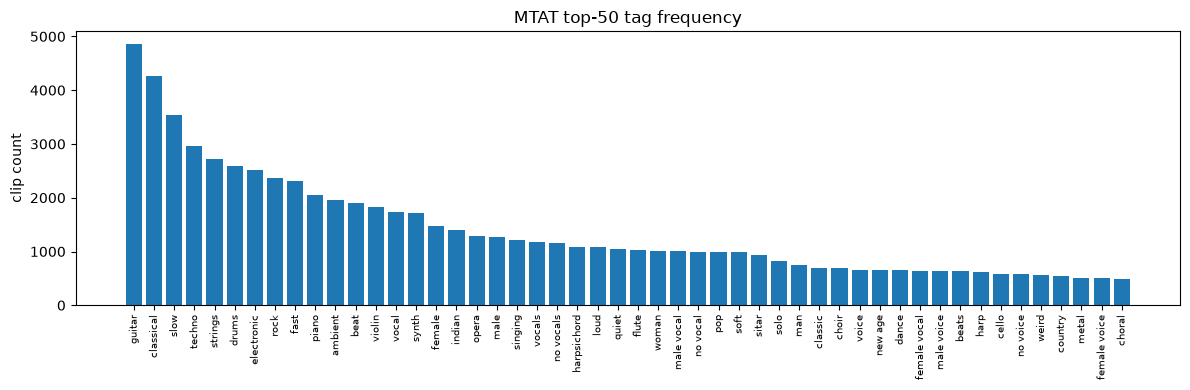

In [2]:
Y = np.array([c['y'] for c in clips.values()])
counts = Y.sum(0)
order = np.argsort(-counts)
plt.figure(figsize=(12,4))
plt.bar(range(len(tags)), counts[order])
plt.xticks(range(len(tags)), [tags[i] for i in order], rotation=90, fontsize=7)
plt.ylabel('clip count'); plt.title('MTAT top-50 tag frequency'); plt.tight_layout(); plt.show()

## Graph size distribution (nodes per clip)

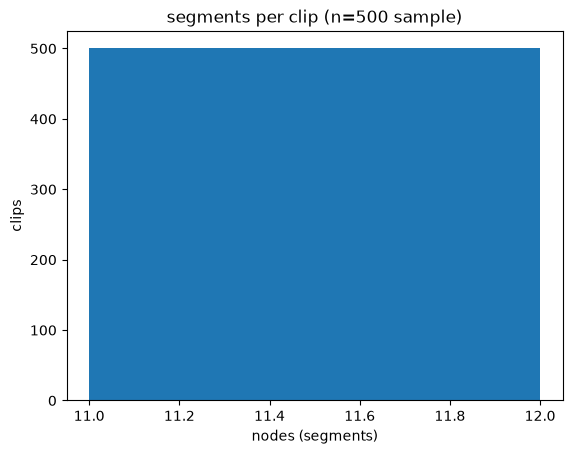

mean nodes: 11.0


In [3]:
import torch
gdir = proc / 'graphs' / 'mtat'
sample = list(gdir.glob('*.pt'))[:500]
nn = [torch.load(p, weights_only=False).x.shape[0] for p in sample]
plt.hist(nn, bins=range(min(nn), max(nn)+2)); plt.xlabel('nodes (segments)'); plt.ylabel('clips')
plt.title(f'segments per clip (n={len(sample)} sample)'); plt.show()
print('mean nodes:', np.mean(nn))

## One clip graph (PyG -> networkx)

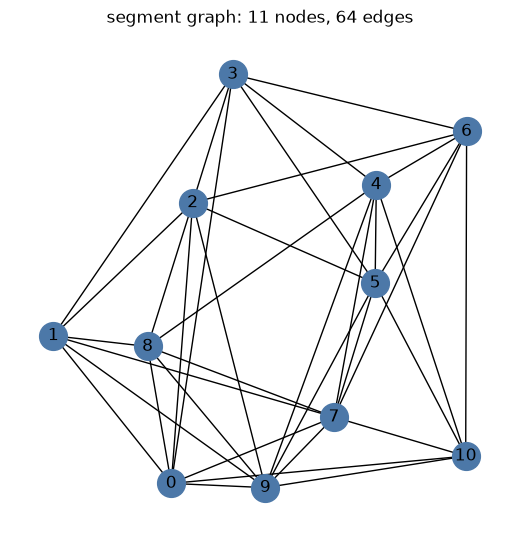

In [4]:
import networkx as nx
g = torch.load(sample[0], weights_only=False)
G = nx.Graph()
G.add_nodes_from(range(g.x.shape[0]))
ei = g.edge_index.numpy()
G.add_edges_from(zip(ei[0], ei[1]))
plt.figure(figsize=(5,5))
nx.draw(G, nx.spring_layout(G, seed=42), with_labels=True, node_color='#4C78A8', node_size=400)
plt.title(f'segment graph: {g.x.shape[0]} nodes, {g.edge_index.shape[1]} edges'); plt.show()

## Log-mel spectrogram example

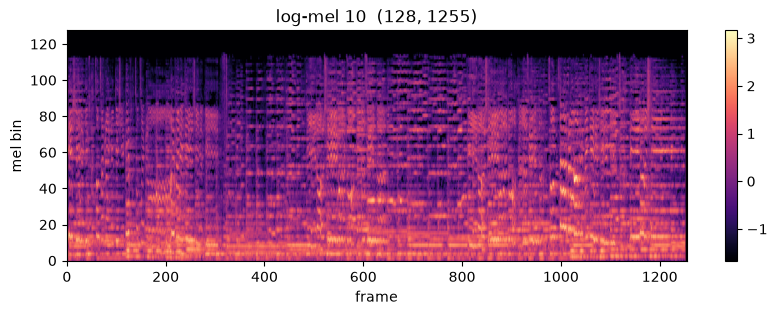

In [5]:
cid = sample[0].stem
mel = np.load(proc / 'mel' / f'{cid}.npy')
plt.figure(figsize=(10,3)); plt.imshow(mel, aspect='auto', origin='lower', cmap='magma')
plt.xlabel('frame'); plt.ylabel('mel bin'); plt.title(f'log-mel {cid}  {mel.shape}'); plt.colorbar(); plt.show()